In [2]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt


In [3]:
RUN_DIR_svd = Path("state_spectrum_sweep/experiments/hf_low_rank_20260415_105529")
RUN_DIR_q = Path("state_spectrum_sweep/experiments/hf_quant_20260415_111241")

assert RUN_DIR_svd.exists(), f"Run directory not found: {RUN_DIR_svd}"
assert RUN_DIR_q.exists(), f"Run directory not found: {RUN_DIR_q}"

RUN_DIR_svd, RUN_DIR_q


(PosixPath('state_spectrum_sweep/experiments/hf_low_rank_20260415_105529'),
 PosixPath('state_spectrum_sweep/experiments/hf_quant_20260415_111241'))

In [4]:
def load_json(path: Path):
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)

def load_tensor(path: Path):
    return torch.load(path, map_location="cpu")

def prompt_ids(run_dir: Path):
    return sorted({p.name.split("_meta.json")[0] for p in run_dir.glob("prompt_*_meta.json")})

def load_prompt_artifacts(run_dir: Path, prompt_id: str):
    meta_path = run_dir / f"{prompt_id}_meta.json"
    text_path = run_dir / f"{prompt_id}_prompt_response.txt"

    artifacts = {
        "prompt_id": prompt_id,
        "meta": load_json(meta_path) if meta_path.exists() else None,
        "response_text": text_path.read_text(encoding="utf-8") if text_path.exists() else None,
    }

    for metric_name in ["kl", "mse", "rel_frob", "cosine_similarity", "retained_energy"]:
        tensor_path = run_dir / f"{prompt_id}_{metric_name}.pt"
        artifacts[metric_name] = load_tensor(tensor_path) if tensor_path.exists() else None

    return artifacts

def load_run(run_dir: Path):
    ids = prompt_ids(run_dir)
    return [load_prompt_artifacts(run_dir, prompt_id) for prompt_id in ids]

all_prompt_ids_svd = prompt_ids(RUN_DIR_svd)
all_prompt_ids_q = prompt_ids(RUN_DIR_q)

all_prompt_ids_svd, all_prompt_ids_q[:5]


(['prompt_01',
  'prompt_02',
  'prompt_03',
  'prompt_04',
  'prompt_05',
  'prompt_06',
  'prompt_07',
  'prompt_08',
  'prompt_09',
  'prompt_10'],
 ['prompt_01', 'prompt_02', 'prompt_03', 'prompt_04', 'prompt_05'])

In [5]:
all_prompt_ids_q = prompt_ids(RUN_DIR_q)
all_prompt_ids_q

['prompt_01',
 'prompt_02',
 'prompt_03',
 'prompt_04',
 'prompt_05',
 'prompt_06',
 'prompt_07',
 'prompt_08',
 'prompt_09',
 'prompt_10']

In [6]:
records_svd = load_run(RUN_DIR_svd)
records_q = load_run(RUN_DIR_q)

len(records_svd), len(records_q)


(10, 10)

In [7]:
def index_by_prompt(records):
    return {r["prompt_id"]: r for r in records}

records_svd_by_id = index_by_prompt(records_svd)
records_q_by_id = index_by_prompt(records_q)

common_prompt_ids = sorted(set(records_svd_by_id) & set(records_q_by_id))
common_prompt_ids


['prompt_01',
 'prompt_02',
 'prompt_03',
 'prompt_04',
 'prompt_05',
 'prompt_06',
 'prompt_07',
 'prompt_08',
 'prompt_09',
 'prompt_10']

In [11]:
# Quick metadata check
meta_example_svd = records_svd_by_id[common_prompt_ids[0]]["meta"]
meta_example_q = records_q_by_id[common_prompt_ids[0]]["meta"]

meta_example_svd, meta_example_q

({'prompt_len': 7,
  'num_generated_tokens': 200,
  'num_metric_steps': 200,
  'stopped_reason': 'max_new_tokens',
  'prefill_seconds': 0.9852379759977339,
  'average_transform_seconds': 0.29558662607996666,
  'num_state_tensors': 128,
  'state_tensor_names': ['layers.0.conv_states',
   'layers.0.recurrent_states',
   'layers.1.conv_states',
   'layers.1.recurrent_states',
   'layers.2.conv_states',
   'layers.2.recurrent_states',
   'layers.3.conv_states',
   'layers.3.recurrent_states',
   'layers.4.conv_states',
   'layers.4.recurrent_states',
   'layers.5.conv_states',
   'layers.5.recurrent_states',
   'layers.6.conv_states',
   'layers.6.recurrent_states',
   'layers.7.conv_states',
   'layers.7.recurrent_states',
   'layers.8.conv_states',
   'layers.8.recurrent_states',
   'layers.9.conv_states',
   'layers.9.recurrent_states',
   'layers.10.conv_states',
   'layers.10.recurrent_states',
   'layers.11.conv_states',
   'layers.11.recurrent_states',
   'layers.12.conv_states',
  

In [12]:
def summarize_step_layer_tensor(x: torch.Tensor):
    x = x.float().cpu()
    out = {
        "shape": tuple(x.shape),
        "mean": float(x.mean().item()),
        "std": float(x.std().item()) if x.numel() > 1 else 0.0,
        "min": float(x.min().item()),
        "max": float(x.max().item()),
    }

    if x.ndim >= 2:
        out["mean_over_layers_per_step"] = x.mean(dim=1)
        out["max_over_layers_per_step"] = x.max(dim=1).values
        out["mean_over_steps_per_layer"] = x.mean(dim=0)
        out["max_over_steps_per_layer"] = x.max(dim=0).values
    elif x.ndim == 1:
        out["per_step"] = x
    return out


In [13]:
def run_summary_dataframe(records, label):
    rows = []
    for rec in records:
        meta = rec["meta"] or {}
        row = {
            "run_type": label,
            "prompt_id": rec["prompt_id"],
            "experiment": meta.get("experiment"),
            "subset": meta.get("subset"),
            "prompt_len": meta.get("prompt_len"),
            "num_generated_tokens": meta.get("num_generated_tokens"),
            "num_metric_steps": meta.get("num_metric_steps"),
            "stopped_reason": meta.get("stopped_reason"),
            "prefill_seconds": meta.get("prefill_seconds"),
            "average_transform_seconds": meta.get("average_transform_seconds"),
            "num_state_tensors": meta.get("num_state_tensors"),
        }

        for metric_name in ["kl", "mse", "rel_frob", "cosine_similarity", "retained_energy"]:
            tensor = rec[metric_name]
            if tensor is None:
                continue
            stats = summarize_step_layer_tensor(tensor)
            row[f"{metric_name}_mean"] = stats["mean"]
            row[f"{metric_name}_std"] = stats["std"]
            row[f"{metric_name}_min"] = stats["min"]
            row[f"{metric_name}_max"] = stats["max"]

            if tensor.ndim == 1:
                row[f"{metric_name}_median"] = float(tensor.float().median().item())
                row[f"{metric_name}_p99"] = float(torch.quantile(tensor.float(), 0.99).item())

        rows.append(row)
    return pd.DataFrame(rows).sort_values(["run_type", "prompt_id"]).reset_index(drop=True)

df_svd = run_summary_dataframe(records_svd, "low_rank")
df_q = run_summary_dataframe(records_q, "quant")
df_all = pd.concat([df_svd, df_q], ignore_index=True)

df_all

,run_type,prompt_id,experiment,subset,prompt_len,num_generated_tokens,num_metric_steps,stopped_reason,prefill_seconds,average_transform_seconds,...,rel_frob_min,rel_frob_max,cosine_similarity_mean,cosine_similarity_std,cosine_similarity_min,cosine_similarity_max,retained_energy_mean,retained_energy_std,retained_energy_min,retained_energy_max
0,low_rank,prompt_01,low_rank,auto,7,200,200,max_new_tokens,0.985238,0.295587,...,0.000000,0.003189,1.000010,0.004060,0.992188,1.007812,1.000000,0.000000,1.000000,1.0
1,low_rank,prompt_02,low_rank,auto,8,200,200,max_new_tokens,0.045963,0.300108,...,0.000000,0.003937,0.999985,0.004000,0.992188,1.007812,1.000000,0.000000,1.000000,1.0
2,low_rank,prompt_03,low_rank,auto,9,200,200,max_new_tokens,0.169418,0.293459,...,0.000000,0.003815,0.999975,0.003999,0.992188,1.007812,1.000000,0.000000,1.000000,1.0
3,low_rank,prompt_04,low_rank,auto,12,200,200,max_new_tokens,0.069176,0.283669,...,0.000000,0.003586,1.000016,0.004028,0.992188,1.007812,1.000000,0.000000,1.000000,1.0
4,low_rank,prompt_05,low_rank,auto,14,200,200,max_new_tokens,0.233388,0.295967,...,0.000000,0.003433,0.999968,0.003996,0.992188,1.007812,1.000000,0.000000,1.000000,1.0
5,low_rank,prompt_06,low_rank,auto,14,200,200,max_new_tokens,0.056088,0.286702,...,0.000000,0.003540,0.999979,0.003981,0.992188,1.007812,1.000000,0.000000,1.000000,1.0
6,low_rank,prompt_07,low_rank,auto,14,200,200,max_new_tokens,0.056485,0.291191,...,0.000000,0.003326,0.999962,0.003902,0.992188,1.007812,1.000000,0.000000,1.000000,1.0
7,low_rank,prompt_08,low_rank,auto,10,200,200,max_new_tokens,0.048380,0.299541,...,0.000000,0.004120,1.000002,0.003968,0.992188,1.007812,1.000000,0.000000,1.000000,1.0
8,low_rank,prompt_09,low_rank,auto,12,200,200,max_new_tokens,0.052701,0.296387,...,0.000000,0.004150,0.999963,0.003997,0.992188,1.007812,1.000000,0.000000,1.000000,1.0
9,low_rank,prompt_10,low_rank,auto,13,200,200,max_new_tokens,0.052876,0.305339,...,0.000000,0.004700,1.000004,0.004022,0.992188,1.007812,1.000000,0.000000,1.000000,1.0


In [14]:
# Verify whether the retained energy tensor really contains only ones
x = records_svd_by_id["prompt_02"]["retained_energy"]
torch.unique(x)

tensor([1.])

In [15]:
# Join SVD and quant by prompt_id for direct comparison
paired = df_svd.merge(df_q, on="prompt_id", suffixes=("_svd", "_q"))
paired.head()


,run_type_svd,prompt_id,experiment_svd,subset_svd,prompt_len_svd,num_generated_tokens_svd,num_metric_steps_svd,stopped_reason_svd,prefill_seconds_svd,average_transform_seconds_svd,...,rel_frob_min_q,rel_frob_max_q,cosine_similarity_mean_q,cosine_similarity_std_q,cosine_similarity_min_q,cosine_similarity_max_q,retained_energy_mean_q,retained_energy_std_q,retained_energy_min_q,retained_energy_max_q
0,low_rank,prompt_01,low_rank,auto,7,200,200,max_new_tokens,0.985238,0.295587,...,0.010071,0.193359,0.998697,0.003574,0.980469,1.007812,0.997986,0.003680,0.960938,1.0
1,low_rank,prompt_02,low_rank,auto,8,200,200,max_new_tokens,0.045963,0.300108,...,0.012024,0.205078,0.998503,0.003976,0.976562,1.007812,0.997491,0.004829,0.957031,1.0
2,low_rank,prompt_03,low_rank,auto,9,200,200,max_new_tokens,0.169418,0.293459,...,0.012024,0.230469,0.998548,0.003891,0.972656,1.007812,0.997538,0.004770,0.945312,1.0
3,low_rank,prompt_04,low_rank,auto,12,200,200,max_new_tokens,0.069176,0.283669,...,0.011658,0.183594,0.998535,0.003851,0.980469,1.007812,0.997464,0.004608,0.964844,1.0
4,low_rank,prompt_05,low_rank,auto,14,200,200,max_new_tokens,0.233388,0.295967,...,0.010864,0.187500,0.998682,0.003609,0.976562,1.007812,0.997923,0.003793,0.964844,1.0


In [16]:
df_all.columns.tolist()

['run_type',
 'prompt_id',
 'experiment',
 'subset',
 'prompt_len',
 'num_generated_tokens',
 'num_metric_steps',
 'stopped_reason',
 'prefill_seconds',
 'average_transform_seconds',
 'num_state_tensors',
 'kl_mean',
 'kl_std',
 'kl_min',
 'kl_max',
 'kl_median',
 'kl_p99',
 'mse_mean',
 'mse_std',
 'mse_min',
 'mse_max',
 'rel_frob_mean',
 'rel_frob_std',
 'rel_frob_min',
 'rel_frob_max',
 'cosine_similarity_mean',
 'cosine_similarity_std',
 'cosine_similarity_min',
 'cosine_similarity_max',
 'retained_energy_mean',
 'retained_energy_std',
 'retained_energy_min',
 'retained_energy_max']

In [17]:
# 1. Single-prompt deep dive, mirroring the original notebook
PROMPT_ID = common_prompt_ids[1] if len(common_prompt_ids) > 1 else common_prompt_ids[0]

rec_svd = records_svd_by_id[PROMPT_ID]
rec_q = records_q_by_id[PROMPT_ID]

kl_svd = rec_svd["kl"].float().cpu()
mse_svd = rec_svd["mse"].float().cpu()
rf_svd = rec_svd["rel_frob"].float().cpu()
cos_svd = rec_svd["cosine_similarity"].float().cpu()
re_svd = rec_svd["retained_energy"].float().cpu()

kl_q = rec_q["kl"].float().cpu()
mse_q = rec_q["mse"].float().cpu()
rf_q = rec_q["rel_frob"].float().cpu()
cos_q = rec_q["cosine_similarity"].float().cpu()
re_q = rec_q["retained_energy"].float().cpu()

steps_svd = np.arange(len(kl_svd))
steps_q = np.arange(len(kl_q))

log_kl_svd = torch.log1p(kl_svd)
log_kl_q = torch.log1p(kl_q)

rf_mean_svd = rf_svd.mean(dim=1)
rf_max_svd = rf_svd.max(dim=1).values
rf_tail_svd = rf_svd[:, -4:].mean(dim=1)

mse_mean_svd = mse_svd.mean(dim=1)
mse_max_svd = mse_svd.max(dim=1).values

re_mean_svd = re_svd.mean(dim=1)
re_min_svd = re_svd.min(dim=1).values

cos_mean_svd = cos_svd.mean(dim=1)
cos_min_svd = cos_svd.min(dim=1).values

rf_mean_q = rf_q.mean(dim=1)
rf_max_q = rf_q.max(dim=1).values
rf_tail_q = rf_q[:, -4:].mean(dim=1)

mse_mean_q = mse_q.mean(dim=1)
mse_max_q = mse_q.max(dim=1).values

re_mean_q = re_q.mean(dim=1)
re_min_q = re_q.min(dim=1).values

cos_mean_q = cos_q.mean(dim=1)
cos_min_q = cos_q.min(dim=1).values

high_mask_svd = kl_svd >= torch.quantile(kl_svd, 0.9)
high_mask_q = kl_q >= torch.quantile(kl_q, 0.9)

print("PROMPT_ID:", PROMPT_ID)
print("SVD high-KL steps:", torch.where(high_mask_svd)[0].tolist())
print("Q high-KL steps:", torch.where(high_mask_q)[0].tolist())


PROMPT_ID: prompt_02
SVD high-KL steps: [7, 11, 14, 16, 20, 21, 26, 30, 38, 39, 41, 43, 46, 49, 60, 63, 86, 102, 158, 192]
Q high-KL steps: [3, 4, 6, 7, 9, 12, 19, 22, 24, 26, 38, 39, 52, 54, 56, 62, 65, 75, 104, 128]


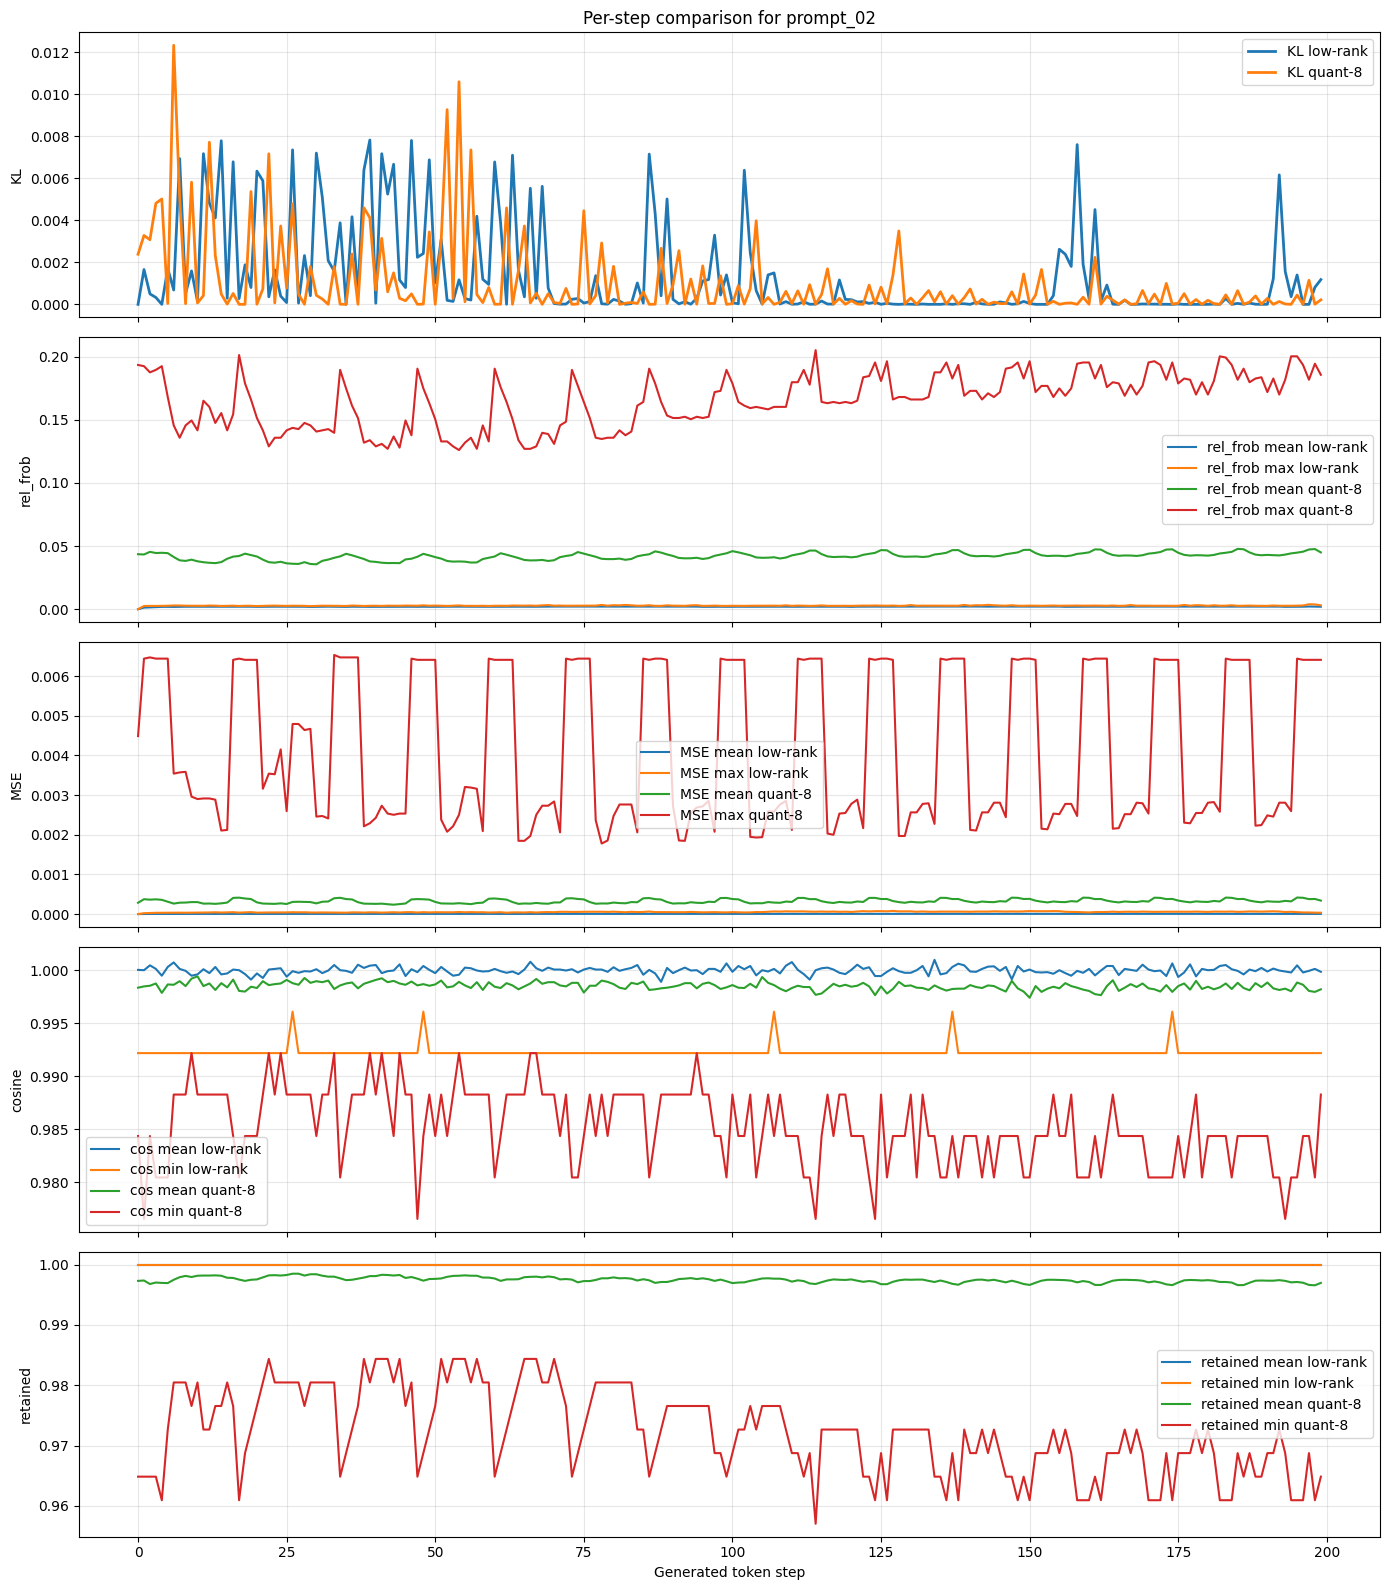

In [18]:
fig, axes = plt.subplots(5, 1, figsize=(14, 16), sharex=True)

axes[0].plot(steps_svd, kl_svd.numpy(), label="KL low-rank", linewidth=2)
axes[0].plot(steps_q, kl_q.numpy(), label="KL quant-8", linewidth=2)
axes[0].set_ylabel("KL")
axes[0].set_title(f"Per-step comparison for {PROMPT_ID}")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(steps_svd, rf_mean_svd.numpy(), label="rel_frob mean low-rank")
axes[1].plot(steps_svd, rf_max_svd.numpy(), label="rel_frob max low-rank")
axes[1].plot(steps_q, rf_mean_q.numpy(), label="rel_frob mean quant-8")
axes[1].plot(steps_q, rf_max_q.numpy(), label="rel_frob max quant-8")
axes[1].set_ylabel("rel_frob")
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].plot(steps_svd, mse_mean_svd.numpy(), label="MSE mean low-rank")
axes[2].plot(steps_svd, mse_max_svd.numpy(), label="MSE max low-rank")
axes[2].plot(steps_q, mse_mean_q.numpy(), label="MSE mean quant-8")
axes[2].plot(steps_q, mse_max_q.numpy(), label="MSE max quant-8")
axes[2].set_ylabel("MSE")
axes[2].legend()
axes[2].grid(alpha=0.3)

axes[3].plot(steps_svd, cos_mean_svd.numpy(), label="cos mean low-rank")
axes[3].plot(steps_svd, cos_min_svd.numpy(), label="cos min low-rank")
axes[3].plot(steps_q, cos_mean_q.numpy(), label="cos mean quant-8")
axes[3].plot(steps_q, cos_min_q.numpy(), label="cos min quant-8")
axes[3].set_ylabel("cosine")
axes[3].legend()
axes[3].grid(alpha=0.3)

axes[4].plot(steps_svd, re_mean_svd.numpy(), label="retained mean low-rank")
axes[4].plot(steps_svd, re_min_svd.numpy(), label="retained min low-rank")
axes[4].plot(steps_q, re_mean_q.numpy(), label="retained mean quant-8")
axes[4].plot(steps_q, re_min_q.numpy(), label="retained min quant-8")
axes[4].set_ylabel("retained")
axes[4].set_xlabel("Generated token step")
axes[4].legend()
axes[4].grid(alpha=0.3)

plt.tight_layout()
plt.show()


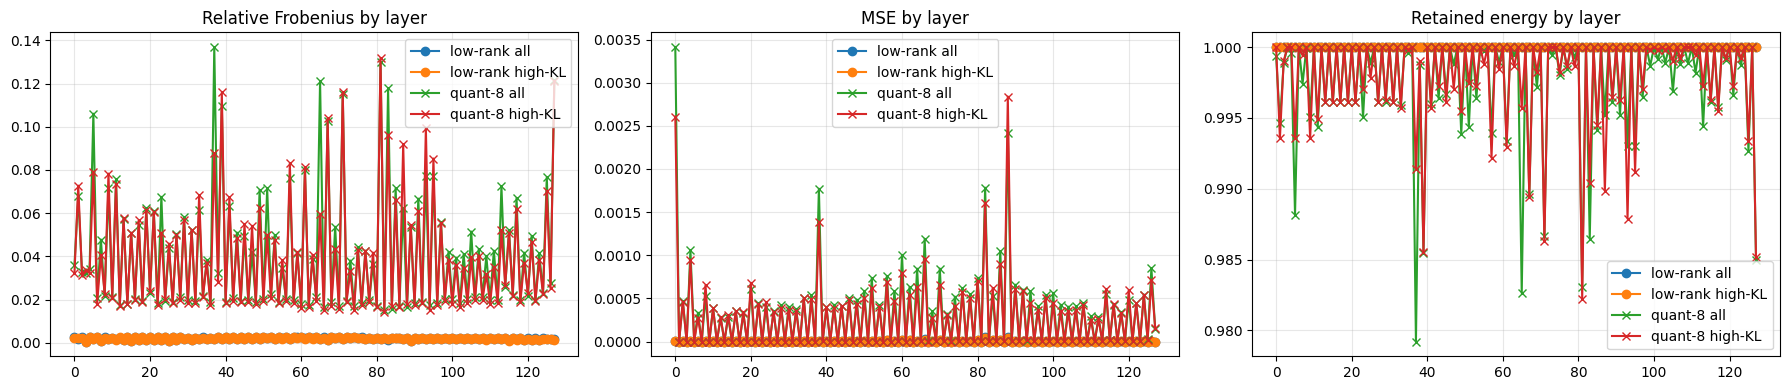

In [19]:
# 2. Layer profiles for one prompt: all steps vs high-KL steps
layers = np.arange(rf_svd.shape[1])

rf_base_svd = rf_svd.mean(dim=0)
rf_high_svd = rf_svd[high_mask_svd].mean(dim=0)
mse_base_svd = mse_svd.mean(dim=0)
mse_high_svd = mse_svd[high_mask_svd].mean(dim=0)
re_base_svd = re_svd.mean(dim=0)
re_high_svd = re_svd[high_mask_svd].mean(dim=0)

rf_base_q = rf_q.mean(dim=0)
rf_high_q = rf_q[high_mask_q].mean(dim=0)
mse_base_q = mse_q.mean(dim=0)
mse_high_q = mse_q[high_mask_q].mean(dim=0)
re_base_q = re_q.mean(dim=0)
re_high_q = re_q[high_mask_q].mean(dim=0)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(layers, rf_base_svd.numpy(), marker="o", label="low-rank all")
axes[0].plot(layers, rf_high_svd.numpy(), marker="o", label="low-rank high-KL")
axes[0].plot(layers, rf_base_q.numpy(), marker="x", label="quant-8 all")
axes[0].plot(layers, rf_high_q.numpy(), marker="x", label="quant-8 high-KL")
axes[0].set_title("Relative Frobenius by layer")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(layers, mse_base_svd.numpy(), marker="o", label="low-rank all")
axes[1].plot(layers, mse_high_svd.numpy(), marker="o", label="low-rank high-KL")
axes[1].plot(layers, mse_base_q.numpy(), marker="x", label="quant-8 all")
axes[1].plot(layers, mse_high_q.numpy(), marker="x", label="quant-8 high-KL")
axes[1].set_title("MSE by layer")
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].plot(layers, re_base_svd.numpy(), marker="o", label="low-rank all")
axes[2].plot(layers, re_high_svd.numpy(), marker="o", label="low-rank high-KL")
axes[2].plot(layers, re_base_q.numpy(), marker="x", label="quant-8 all")
axes[2].plot(layers, re_high_q.numpy(), marker="x", label="quant-8 high-KL")
axes[2].set_title("Retained energy by layer")
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [20]:
# 3. Prompt-level KL summaries, mirroring the original notebook
def get_kl_tensors(records):
    return [r["kl"].float().cpu().numpy() for r in records if r["kl"] is not None]

kl_tensors_svd = get_kl_tensors(records_svd)
kl_tensors_q = get_kl_tensors(records_q)

def trimmed_mean(arr, percentiles=(10, 90)):
    bottom, top = np.percentile(arr, percentiles)
    trimmed = arr[(arr >= bottom) & (arr <= top)]
    return float(np.mean(trimmed))

def spike_rate(arr, spike_threshold=2.0):
    return float(np.mean(arr > spike_threshold))

kl_median_svd = [np.median(t) for t in kl_tensors_svd]
kl_median_q = [np.median(t) for t in kl_tensors_q]

kl_trimmed_mean_svd = [trimmed_mean(t) for t in kl_tensors_svd]
kl_trimmed_mean_q = [trimmed_mean(t) for t in kl_tensors_q]

kl_p99_svd = [np.percentile(t, 99) for t in kl_tensors_svd]
kl_p99_q = [np.percentile(t, 99) for t in kl_tensors_q]

spike_rates_svd = [spike_rate(t) for t in kl_tensors_svd]
spike_rates_q = [spike_rate(t) for t in kl_tensors_q]

print("Average spike rate low-rank:", np.mean(spike_rates_svd))
print("Average spike rate quant-8:", np.mean(spike_rates_q))


Average spike rate low-rank: 0.0
Average spike rate quant-8: 0.0


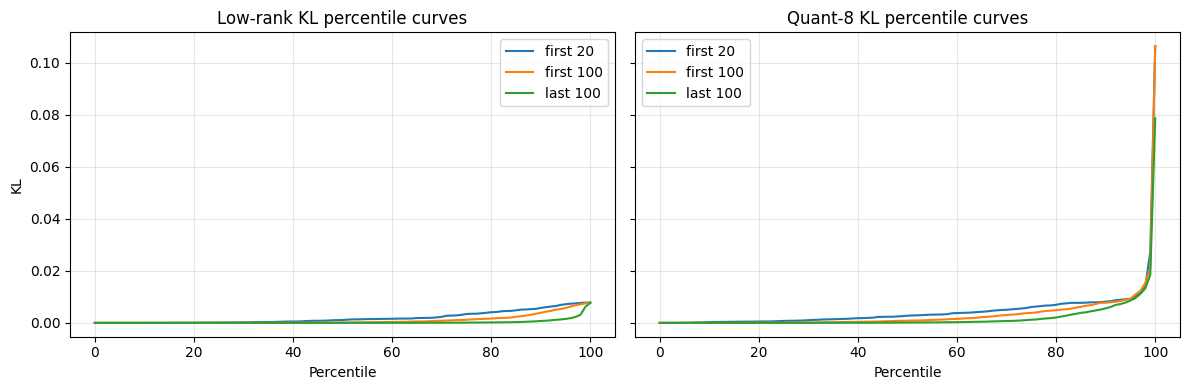

In [21]:
# 4. Percentile curves for early vs late generated tokens
def flatten_numeric(values):
    flat = []
    for v in values:
        flat.extend(np.asarray(v).ravel().tolist())
    return np.asarray(flat, dtype=float)

def crop_prefix(tensors, n):
    return [t[: min(n, len(t))] for t in tensors]

def crop_suffix(tensors, n):
    return [t[-min(n, len(t)):] for t in tensors]

percentiles = np.linspace(0, 100, 101)

svd_first20 = flatten_numeric(crop_prefix(kl_tensors_svd, 20))
svd_first100 = flatten_numeric(crop_prefix(kl_tensors_svd, 100))
svd_last100 = flatten_numeric(crop_suffix(kl_tensors_svd, 100))

q_first20 = flatten_numeric(crop_prefix(kl_tensors_q, 20))
q_first100 = flatten_numeric(crop_prefix(kl_tensors_q, 100))
q_last100 = flatten_numeric(crop_suffix(kl_tensors_q, 100))

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

axes[0].plot(percentiles, np.percentile(svd_first20, percentiles), label="first 20")
axes[0].plot(percentiles, np.percentile(svd_first100, percentiles), label="first 100")
axes[0].plot(percentiles, np.percentile(svd_last100, percentiles), label="last 100")
axes[0].set_title("Low-rank KL percentile curves")
axes[0].set_xlabel("Percentile")
axes[0].set_ylabel("KL")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(percentiles, np.percentile(q_first20, percentiles), label="first 20")
axes[1].plot(percentiles, np.percentile(q_first100, percentiles), label="first 100")
axes[1].plot(percentiles, np.percentile(q_last100, percentiles), label="last 100")
axes[1].set_title("Quant-8 KL percentile curves")
axes[1].set_xlabel("Percentile")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [22]:
# 5. Direct paired comparison across prompts
comparison = pd.DataFrame({
    "prompt_id": common_prompt_ids,
    "kl_mean_low_rank": [
        float(records_svd_by_id[p]["kl"].float().mean().item()) for p in common_prompt_ids
    ],
    "kl_mean_quant_8": [
        float(records_q_by_id[p]["kl"].float().mean().item()) for p in common_prompt_ids
    ],
    "mse_mean_low_rank": [
        float(records_svd_by_id[p]["mse"].float().mean().item()) for p in common_prompt_ids
    ],
    "mse_mean_quant_8": [
        float(records_q_by_id[p]["mse"].float().mean().item()) for p in common_prompt_ids
    ],
    "rel_frob_mean_low_rank": [
        float(records_svd_by_id[p]["rel_frob"].float().mean().item()) for p in common_prompt_ids
    ],
    "rel_frob_mean_quant_8": [
        float(records_q_by_id[p]["rel_frob"].float().mean().item()) for p in common_prompt_ids
    ],
    "cos_mean_low_rank": [
        float(records_svd_by_id[p]["cosine_similarity"].float().mean().item()) for p in common_prompt_ids
    ],
    "cos_mean_quant_8": [
        float(records_q_by_id[p]["cosine_similarity"].float().mean().item()) for p in common_prompt_ids
    ],
    "retained_mean_low_rank": [
        float(records_svd_by_id[p]["retained_energy"].float().mean().item()) for p in common_prompt_ids
    ],
    "retained_mean_quant_8": [
        float(records_q_by_id[p]["retained_energy"].float().mean().item()) for p in common_prompt_ids
    ],
})

comparison["kl_mean_diff"] = comparison["kl_mean_quant_8"] - comparison["kl_mean_low_rank"]
comparison["mse_mean_diff"] = comparison["mse_mean_quant_8"] - comparison["mse_mean_low_rank"]
comparison["rel_frob_mean_diff"] = comparison["rel_frob_mean_quant_8"] - comparison["rel_frob_mean_low_rank"]
comparison["cos_mean_diff"] = comparison["cos_mean_quant_8"] - comparison["cos_mean_low_rank"]
comparison["retained_mean_diff"] = comparison["retained_mean_quant_8"] - comparison["retained_mean_low_rank"]

comparison


,prompt_id,kl_mean_low_rank,kl_mean_quant_8,mse_mean_low_rank,mse_mean_quant_8,rel_frob_mean_low_rank,rel_frob_mean_quant_8,cos_mean_low_rank,cos_mean_quant_8,retained_mean_low_rank,retained_mean_quant_8,kl_mean_diff,mse_mean_diff,rel_frob_mean_diff,cos_mean_diff,retained_mean_diff
0,prompt_01,0.001136,0.004752,0.000005,0.000338,0.002076,0.039318,1.000010,0.998697,1.0,0.997986,0.003616,0.000333,0.037242,-0.001313,-0.002014
1,prompt_02,0.001383,0.001020,0.000005,0.000324,0.002010,0.041991,0.999985,0.998503,1.0,0.997491,-0.000364,0.000319,0.039982,-0.001482,-0.002509
2,prompt_03,0.000677,0.000596,0.000004,0.000318,0.001937,0.042205,0.999975,0.998548,1.0,0.997538,-0.000082,0.000314,0.040267,-0.001427,-0.002462
3,prompt_04,0.000552,0.000848,0.000004,0.000315,0.001800,0.042130,1.000016,0.998535,1.0,0.997464,0.000296,0.000310,0.040330,-0.001480,-0.002536
4,prompt_05,0.000472,0.003229,0.000005,0.000293,0.002057,0.039440,0.999968,0.998682,1.0,0.997923,0.002757,0.000288,0.037383,-0.001286,-0.002077
5,prompt_06,0.000463,0.001947,0.000004,0.000299,0.001790,0.039984,0.999979,0.998659,1.0,0.997762,0.001484,0.000295,0.038194,-0.001320,-0.002238
6,prompt_07,0.000248,0.003921,0.000004,0.000315,0.001907,0.039363,0.999962,0.998702,1.0,0.998039,0.003673,0.000311,0.037456,-0.001260,-0.001961
7,prompt_08,0.000518,0.002166,0.000005,0.000318,0.001936,0.042994,1.000002,0.998419,1.0,0.997364,0.001648,0.000313,0.041057,-0.001582,-0.002636
8,prompt_09,0.000848,0.003886,0.000004,0.000303,0.001938,0.038394,0.999963,0.998766,1.0,0.998165,0.003038,0.000298,0.036456,-0.001197,-0.001835
9,prompt_10,0.000462,0.000469,0.000004,0.000297,0.001804,0.042204,1.000004,0.998460,1.0,0.997368,0.000008,0.000293,0.040400,-0.001545,-0.002632


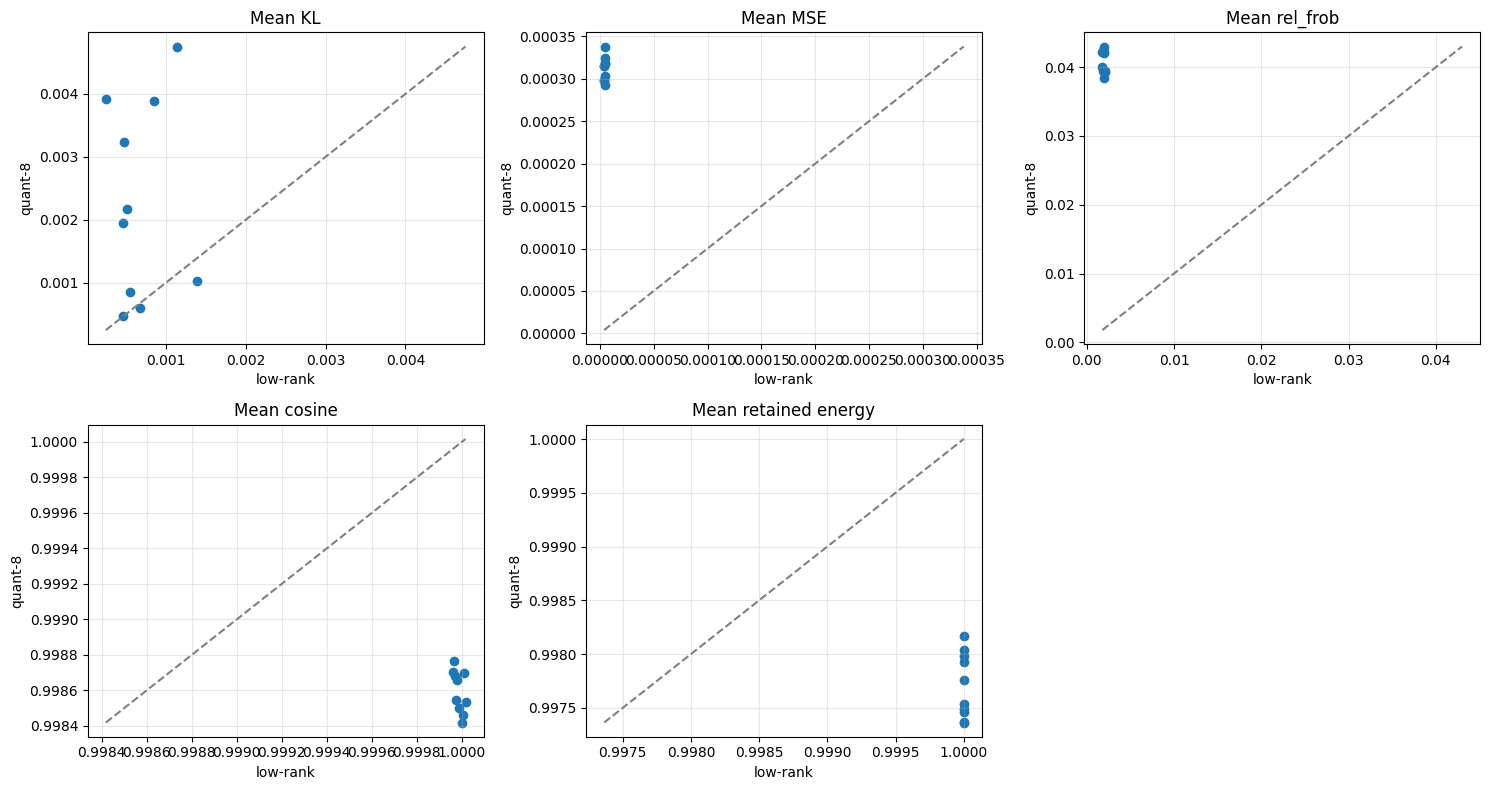

In [23]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

plots = [
    ("kl_mean_low_rank", "kl_mean_quant_8", "Mean KL"),
    ("mse_mean_low_rank", "mse_mean_quant_8", "Mean MSE"),
    ("rel_frob_mean_low_rank", "rel_frob_mean_quant_8", "Mean rel_frob"),
    ("cos_mean_low_rank", "cos_mean_quant_8", "Mean cosine"),
    ("retained_mean_low_rank", "retained_mean_quant_8", "Mean retained energy"),
]

for ax, (xcol, ycol, title) in zip(axes.ravel(), plots):
    ax.scatter(comparison[xcol], comparison[ycol])
    lo = min(comparison[xcol].min(), comparison[ycol].min())
    hi = max(comparison[xcol].max(), comparison[ycol].max())
    ax.plot([lo, hi], [lo, hi], linestyle="--", color="gray")
    ax.set_xlabel("low-rank")
    ax.set_ylabel("quant-8")
    ax.set_title(title)
    ax.grid(alpha=0.3)

axes.ravel()[-1].axis("off")
plt.tight_layout()
plt.show()


In [24]:
# 6. Meta.json inspection: state names and timing
meta_rows = []
for prompt_id in common_prompt_ids:
    meta_svd = records_svd_by_id[prompt_id]["meta"]
    meta_q = records_q_by_id[prompt_id]["meta"]
    meta_rows.append({
        "prompt_id": prompt_id,
        "prefill_seconds_low_rank": meta_svd.get("prefill_seconds"),
        "prefill_seconds_quant_8": meta_q.get("prefill_seconds"),
        "average_transform_seconds_low_rank": meta_svd.get("average_transform_seconds"),
        "average_transform_seconds_quant_8": meta_q.get("average_transform_seconds"),
        "num_state_tensors_low_rank": meta_svd.get("num_state_tensors"),
        "num_state_tensors_quant_8": meta_q.get("num_state_tensors"),
    })

meta_df = pd.DataFrame(meta_rows)
meta_df


,prompt_id,prefill_seconds_low_rank,prefill_seconds_quant_8,average_transform_seconds_low_rank,average_transform_seconds_quant_8,num_state_tensors_low_rank,num_state_tensors_quant_8
0,prompt_01,0.985238,0.482630,0.295587,0.090113,128,128
1,prompt_02,0.045963,0.043316,0.300108,0.093720,128,128
2,prompt_03,0.169418,0.047904,0.293459,0.090488,128,128
3,prompt_04,0.069176,0.067493,0.283669,0.084882,128,128
4,prompt_05,0.233388,0.067928,0.295967,0.086190,128,128
5,prompt_06,0.056088,0.054019,0.286702,0.095438,128,128
6,prompt_07,0.056485,0.054317,0.291191,0.099807,128,128
7,prompt_08,0.048380,0.045994,0.299541,0.094899,128,128
8,prompt_09,0.052701,0.050675,0.296387,0.083990,128,128
9,prompt_10,0.052876,0.050296,0.305339,0.085706,128,128


In [25]:
# Inspect state names from one prompt
sample_meta = records_svd_by_id[common_prompt_ids[0]]["meta"]
state_names = sample_meta.get("state_names", [])
state_names[:10], len(state_names)


([], 0)

In [26]:
# Response text side-by-side
prompt_id = common_prompt_ids[0]
print("LOW-RANK RESPONSE\n")
print(records_svd_by_id[prompt_id]["response_text"][:1000])

print("\n" + "=" * 80 + "\n")

print("QUANT-8 RESPONSE\n")
print(records_q_by_id[prompt_id]["response_text"][:1000])


LOW-RANK RESPONSE

PROMPT:
Hi there! Who are you?

RESPONSE:
I'm a freelance writer and editor, most recently for the Daily Dot. I'm also a lifelong writer and editor, having worked at the San Francisco Chronicle, the Chicago Tribune, and the San Jose Mercury News. I'm the author of two books, "The Best American Travel Writing 2009" and "The Best American Travel Writing 2011."

I'm also a regular contributor to the New York Times, the Atlantic, the Washington Post, the Los Angeles Times, the San Francisco Chronicle, the Chicago Tribune, the San Jose Mercury News, and many other publications.

I'm the author of two books, "The Best American Travel Writing 2009" and "The Best American Travel Writing 2011."

I'm also a regular contributor to the New York Times, the Atlantic, the Washington Post, the Los Angeles Times, the San Francisco Chronicle, the Chicago Tribune, the San Jose Mercury News, and many other publications.

I'm the author of two books, "



QUANT-8 RESPONSE

PROMPT:
Hi the